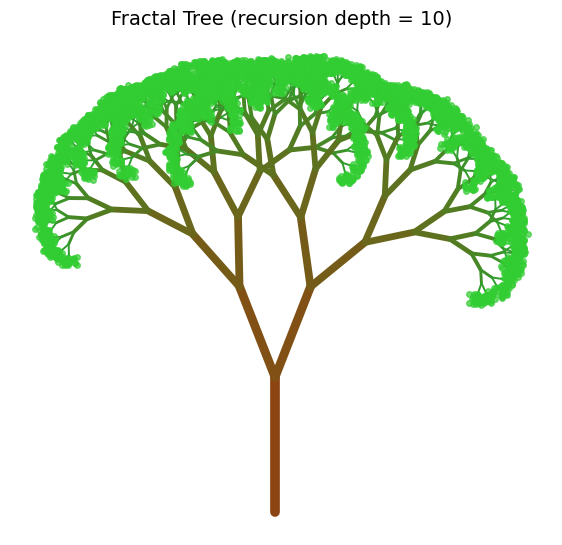

In [1]:
import matplotlib.pyplot as plt
import math
import random

def draw_tree(ax, x, y, angle, length, depth, max_depth, leaves):
    """
    RECURSION: each call draws one branch, then calls itself twice
    (left child, right child) with a shorter length and reduced depth.
    Recursion stops (base case) when depth reaches 0 - at that point
    we just remember the tip position so leaves can be drawn later.
    """
    if depth == 0:
        leaves.append((x, y))
        return

    x2 = x + length * math.cos(math.radians(angle))
    y2 = y + length * math.sin(math.radians(angle))

    # color gradient: brown trunk fading into green towards the tips
    t = 1 - depth / max_depth
    color = (0.55 - 0.45 * t, 0.27 + 0.43 * t, 0.07 + 0.13 * t)
    width = max(1, depth * 0.7)

    ax.plot([x, x2], [y, y2], color=color, linewidth=width, solid_capstyle='round')

    new_length = length * 0.72
    branch_angle = 25 + random.uniform(-5, 5)  # slight randomness = organic look

    draw_tree(ax, x2, y2, angle + branch_angle, new_length, depth - 1, max_depth, leaves)
    draw_tree(ax, x2, y2, angle - branch_angle, new_length, depth - 1, max_depth, leaves)


def generate_fractal_tree(depth=10, length=10):
    fig, ax = plt.subplots(figsize=(7, 8))
    fig.patch.set_facecolor('white')

    leaves = []
    draw_tree(ax, 0, 0, 90, length, depth, depth, leaves)

    # ITERATION: loop over every branch tip collected during recursion
    # and scatter a small cluster of leaf dots around each one.
    for (lx, ly) in leaves:
        for _ in range(6):
            dx = random.uniform(-0.4, 0.4)
            dy = random.uniform(-0.4, 0.4)
            ax.plot(lx + dx, ly + dy, 'o', color='limegreen',
                     markersize=4, alpha=0.7)

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Fractal Tree (recursion depth = {depth})", fontsize=14)
    plt.show()


generate_fractal_tree(depth=10, length=10)